# 🧪 CartPole-v1: Deep Q-Network Research Notebook

---

**Research Lab** · Reinforcement Learning Division  
**Environment** · `CartPole-v1` (OpenAI Gymnasium)  
**Algorithms** · DQN with Target Network · Double DQN  
**Framework** · PyTorch

---

## 1.1 Research Objective

This notebook implements and compares two value-based reinforcement learning algorithms on the CartPole-v1 environment:

1. **DQN with Target Network** — The foundational deep Q-learning approach introduced by Mnih et al. (2015), which uses a separate target network to stabilize training.
2. **Double DQN** — An improvement proposed by van Hasselt et al. (2016) that decouples action selection from action evaluation to reduce overestimation bias.

## 1.2 Research Questions

| # | Question |
|---|----------|
| RQ1 | Can a DQN agent with target network learn to solve CartPole-v1 (achieve reward ≥ 475 over 100 consecutive episodes)? |
| RQ2 | Does Double DQN improve sample efficiency or final performance compared to standard DQN? |
| RQ3 | How do the reward curves differ between the two algorithms across 2000 training episodes? |

## 1.3 Environment Description

CartPole-v1 is a classic control task where the agent must balance a pole on a moving cart.

| Property | Value |
|----------|-------|
| Observation space | `Box(4,)` — [cart position, cart velocity, pole angle, pole angular velocity] |
| Action space | `Discrete(2)` — push left (0) or push right (1) |
| Reward | +1 for every timestep the pole remains upright |
| Max episode length | 500 steps |
| Solved threshold | Mean reward ≥ 475 over 100 consecutive episodes |

---
## 2. Imports

All dependencies are listed here for clarity and reproducibility.

In [5]:
# ═══════════════════════════════════════════════════════════════
# STANDARD LIBRARY
# ═══════════════════════════════════════════════════════════════
import random
import time
from collections import deque

# ═══════════════════════════════════════════════════════════════
# SCIENTIFIC COMPUTING
# ═══════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ═══════════════════════════════════════════════════════════════
# REINFORCEMENT LEARNING
# ═══════════════════════════════════════════════════════════════
import gymnasium as gym

# ═══════════════════════════════════════════════════════════════
# DEEP LEARNING
# ═══════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

print(f"PyTorch version : {torch.__version__}")
print(f"Gymnasium version: {gym.__version__}")

PyTorch version : 2.11.0+cu128
Gymnasium version: 1.3.0


---
## 3. Reproducibility & Device Setup

### Why set seeds?

Reinforcement learning experiments are inherently stochastic. Setting seeds for all random number generators ensures that:

- **Results are reproducible** across runs on the same hardware
- **Debugging is easier** because you can replay the exact same trajectory
- **Comparisons are fair** between algorithm variants

> **Note:** Full determinism on GPU requires `torch.use_deterministic_algorithms(True)`, which may slow training and is not always compatible with all operations. We set CUDA seeds for best-effort reproducibility.

In [ ]:
# 
# REPRODUCIBILITY SEEDS
# 
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Random seed set to {SEED} for: random, numpy, torch, CUDA")

Random seed set to 42 for: random, numpy, torch, CUDA


In [1]:
# ═══════════════════════════════════════════════════════════════
# DEVICE DETECTION
# ═══════════════════════════════════════════════════════════════
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device("mps")
    device_name = "Apple Silicon (MPS)"
else:
    device = torch.device("cpu")
    device_name = "CPU"

print("╔═══════════════════════════════════════════════════╗")
print(f"║  Device      : {device}")
print(f"║  Device Name : {device_name}")
print(f"║  CUDA Avail  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"║  GPU Memory  : {mem:.1f} GB")
print("╚═══════════════════════════════════════════════════╝")


NameError: name 'torch' is not defined

---
## 4. Environment Setup

We use the `CartPole-v1` environment from Gymnasium. The agent receives a continuous 4-dimensional observation and must choose between two discrete actions.

In [8]:
# ═══════════════════════════════════════════════════════════════
# CREATE CARTPOLE ENVIRONMENT
# ═══════════════════════════════════════════════════════════════
env = gym.make("CartPole-v1")

STATE_DIM = env.observation_space.shape[0]
ACTION_DIM = env.action_space.n

ACTION_MAP = {
    0: "Push Left",
    1: "Push Right"
}

print(f"Observation Space : {env.observation_space}")
print(f"Observation Shape : {env.observation_space.shape}")
print(f"Number of Actions : {ACTION_DIM}")
print(f"Action Mapping    : {ACTION_MAP}")

Observation Space : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Observation Shape : (4,)
Number of Actions : 2
Action Mapping    : {0: 'Push Left', 1: 'Push Right'}


---
## 5. Neural Network Architecture

The DQN uses a simple fully-connected architecture:

```
Input (4) → FC(128) + ReLU → FC(128) + ReLU → Output (2)
```

| Layer | Input Dim | Output Dim | Activation |
|-------|-----------|------------|------------|
| `fc1` | 4 (state) | 128 | ReLU |
| `fc2` | 128 | 128 | ReLU |
| `fc3` | 128 | 2 (actions) | None (raw Q-values) |

The network takes a state as input and outputs Q-values for each possible action. No activation is applied to the output layer since Q-values can be any real number.

In [9]:
class DQN(nn.Module):
    """Deep Q-Network for CartPole.
    
    Architecture: 4 → 128 → 128 → 2
    Activation: ReLU on hidden layers
    Output: Raw Q-values (no activation)
    """

    def __init__(self):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(4, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 2)

    def forward(self, x):
        x = F.relu(self.fc1(x))    # Hidden layer 1
        x = F.relu(self.fc2(x))    # Hidden layer 2
        q_values = self.fc3(x)     # Output layer (raw Q-values)
        return q_values


# ── Quick architecture verification ──
_test_model = DQN().to(device)
_sample = torch.FloatTensor([0.1, 0.2, -0.1, 0.5]).to(device)
print(f"Network architecture:\n{_test_model}")
print(f"\nParameter count: {sum(p.numel() for p in _test_model.parameters()):,}")
print(f"Sample Q-values: {_test_model(_sample).detach().cpu().numpy()}")
del _test_model, _sample

Network architecture:
DQN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)

Parameter count: 17,410
Sample Q-values: [ 0.02529069 -0.00412317]


---
## 6. Experience Replay Buffer

The replay buffer stores `(state, action, reward, next_state, done)` transitions and allows uniform random sampling. This breaks temporal correlations in training data and improves learning stability.

**Key parameters:**
- **Capacity**: Maximum number of transitions stored (FIFO eviction)
- **Batch size**: Number of transitions sampled per training step

In [10]:
class ReplayBuffer:
    """Fixed-size replay buffer with uniform random sampling.
    
    Stores (state, action, reward, next_state, done) transitions
    in a FIFO deque with configurable maximum capacity.
    """

    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """Store a single transition."""
        self.memory.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Sample a random mini-batch of transitions."""
        return random.sample(self.memory, batch_size)

    def __len__(self):
        """Return current buffer size."""
        return len(self.memory)


print("ReplayBuffer class defined.")

ReplayBuffer class defined.


---
## 7. Action Selection (ε-Greedy Policy)

The ε-greedy policy balances exploration and exploitation:

- With probability **ε**: choose a random action (exploration)
- With probability **1 − ε**: choose the action with the highest Q-value (exploitation)

ε is decayed over training to shift from exploration toward exploitation.

In [11]:
def epsilon_greedy(state, model, epsilon):
    """Select action using epsilon-greedy policy.
    
    Args:
        state: Current environment observation
        model: Q-network (online model)
        epsilon: Exploration probability [0, 1]
    
    Returns:
        action_index: Selected action (0 or 1)
    """
    if random.uniform(0, 1) < epsilon:
        # ── EXPLORATION: random action ──
        action_index = random.randint(0, 1)
    else:
        # ── EXPLOITATION: greedy action ──
        state_tensor = torch.FloatTensor(state).to(device)
        with torch.no_grad():
            q_values = model(state_tensor)
        action_index = torch.argmax(q_values).item()

    return action_index


print("epsilon_greedy function defined.")

epsilon_greedy function defined.


---
## 8. Training Step

### 8.1 Standard DQN Training Step

The Bellman update for DQN with target network:

$$Q_{\text{target}} = r + \gamma \cdot (1 - \text{done}) \cdot \max_{a'} Q_{\text{target\_net}}(s', a')$$

Loss is computed using Huber loss (SmoothL1Loss) for robustness to outliers. Gradients are clipped to 10 for stability.

In [12]:
def train_step(
    replay_buffer,
    online_model,
    target_model,
    optimizer,
    batch_size=32,
    gamma=0.99
):
    """Perform one DQN training step (standard Bellman update).
    
    Uses the target network for computing max Q(s', a').
    Returns the loss value, or None if buffer is too small.
    """
    if len(replay_buffer) < batch_size:
        return None

    transitions = replay_buffer.sample(batch_size)
    batch = list(zip(*transitions))

    # ── Convert to tensors on device ──
    states      = torch.FloatTensor(np.array(batch[0])).to(device)
    actions     = torch.LongTensor(batch[1]).unsqueeze(1).to(device)
    rewards     = torch.FloatTensor(batch[2]).unsqueeze(1).to(device)
    next_states = torch.FloatTensor(np.array(batch[3])).to(device)
    dones       = torch.FloatTensor(batch[4]).unsqueeze(1).to(device)

    # ── Current Q-values ──
    current_q = online_model(states)
    current_q = current_q.gather(1, actions)

    # ── Target Q-values (no gradient) ──
    with torch.no_grad():
        next_q = target_model(next_states)
        max_next_q = next_q.max(1)[0].unsqueeze(1)
        target_q = rewards + gamma * (1 - dones) * max_next_q

    # ── Loss & backprop ──
    criterion = nn.SmoothL1Loss()
    loss = criterion(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(online_model.parameters(), 10)
    optimizer.step()

    return loss.item()


print("train_step (standard DQN) defined.")

train_step (standard DQN) defined.


### 8.2 Double DQN Training Step

The key difference in Double DQN: the **online network** selects the best action, while the **target network** evaluates it:

$$a^* = \arg\max_{a'} Q_{\text{online}}(s', a')$$
$$Q_{\text{target}} = r + \gamma \cdot (1 - \text{done}) \cdot Q_{\text{target\_net}}(s', a^*)$$

This reduces overestimation bias inherent in standard DQN.

In [13]:
def train_step_double(
    replay_buffer,
    online_model,
    target_model,
    optimizer,
    batch_size=32,
    gamma=0.99
):
    """Perform one Double DQN training step.
    
    Uses online network for action selection, target network
    for action evaluation. Reduces overestimation bias.
    """
    if len(replay_buffer) < batch_size:
        return None

    transitions = replay_buffer.sample(batch_size)
    batch = list(zip(*transitions))

    states      = torch.FloatTensor(np.array(batch[0])).to(device)
    actions     = torch.LongTensor(batch[1]).unsqueeze(1).to(device)
    rewards     = torch.FloatTensor(batch[2]).unsqueeze(1).to(device)
    next_states = torch.FloatTensor(np.array(batch[3])).to(device)
    dones       = torch.FloatTensor(batch[4]).unsqueeze(1).to(device)

    # ── Current Q-values ──
    current_q = online_model(states).gather(1, actions)

    with torch.no_grad():
        # ── Double DQN: online selects, target evaluates ──
        best_actions = online_model(next_states).argmax(1).unsqueeze(1)
        next_q = target_model(next_states).gather(1, best_actions)
        target_q = rewards + gamma * (1 - dones) * next_q

    criterion = nn.SmoothL1Loss()
    loss = criterion(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(online_model.parameters(), 10)
    optimizer.step()

    return loss.item()


print("train_step_double (Double DQN) defined.")

train_step_double (Double DQN) defined.


---
## 9. Training Loop

The training loop handles:
- Episode execution with ε-greedy exploration
- Experience collection into the replay buffer
- Online network training via sampled mini-batches
- Periodic target network synchronization
- ε decay (multiplicative)

In [14]:
def train_agent(
    env,
    replay_buffer,
    online_model,
    target_model,
    optimizer,
    train_step_fn,
    num_episodes=2000,
    epsilon_start=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01,
    target_update_frequency=50,
    batch_size=32,
    gamma=0.99,
    log_interval=100
):
    """Generic training loop for DQN variants.
    
    Args:
        train_step_fn: Either `train_step` (DQN) or `train_step_double` (Double DQN)
        log_interval: Print progress every N episodes
    
    Returns:
        rewards_history: List of total rewards per episode
    """
    epsilon = epsilon_start
    rewards_history = []

    for episode in range(num_episodes):
        state, info = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = epsilon_greedy(state, online_model, epsilon)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward

            if len(replay_buffer) > batch_size:
                train_step_fn(
                    replay_buffer, online_model, target_model,
                    optimizer, batch_size, gamma
                )

        # ── Epsilon decay ──
        if epsilon > epsilon_min:
            epsilon *= epsilon_decay

        # ── Target network update ──
        if episode % target_update_frequency == 0:
            target_model.load_state_dict(online_model.state_dict())

        rewards_history.append(total_reward)

        # ── Logging ──
        if episode % log_interval == 0 or episode == num_episodes - 1:
            recent = rewards_history[-min(100, len(rewards_history)):]
            print(
                f"Episode {episode:>5d}/{num_episodes} │ "
                f"Reward: {total_reward:>6.0f} │ "
                f"Avg(100): {np.mean(recent):>7.1f} │ "
                f"ε: {epsilon:.4f}"
            )

    return rewards_history


print("train_agent function defined.")

train_agent function defined.


---
## 10. Experiment Runner

A reusable experiment runner that:
- Initializes models and optimizer
- Tracks training and evaluation time
- Records comprehensive experiment metadata
- Stores results for cross-experiment comparison

In [15]:
# ═══════════════════════════════════════════════════════════════
# GLOBAL EXPERIMENT TRACKING
# ═══════════════════════════════════════════════════════════════
experiment_results = {}
NOTEBOOK_START_TIME = time.time()


def run_experiment(
    experiment_name,
    algorithm,
    train_step_fn,
    num_episodes=2000,
    lr=0.001,
    batch_size=32,
    gamma=0.99,
    buffer_size=10000,
    target_update_freq=50,
    epsilon_start=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01,
    eval_episodes=10,
):
    """Run a complete experiment with timing, training, and evaluation.
    
    Stores results in the global `experiment_results` dictionary.
    """
    print("\n" + "═" * 70)
    print(f"  EXPERIMENT: {experiment_name}")
    print(f"  Algorithm : {algorithm}")
    print("═" * 70 + "\n")

    # ── Initialize components ──
    exp_env = gym.make("CartPole-v1")
    online_model = DQN().to(device)
    target_model = DQN().to(device)
    target_model.load_state_dict(online_model.state_dict())
    replay_buffer = ReplayBuffer(buffer_size)
    optimizer = optim.Adam(online_model.parameters(), lr=lr)

    # ── Training phase ──
    train_start = time.time()
    rewards = train_agent(
        exp_env, replay_buffer, online_model, target_model, optimizer,
        train_step_fn=train_step_fn,
        num_episodes=num_episodes,
        epsilon_start=epsilon_start,
        epsilon_decay=epsilon_decay,
        epsilon_min=epsilon_min,
        target_update_frequency=target_update_freq,
        batch_size=batch_size,
        gamma=gamma,
    )
    train_time = time.time() - train_start

    # ── Evaluation phase ──
    eval_start = time.time()
    eval_rewards = evaluate_agent(online_model, num_episodes=eval_episodes)
    eval_time = time.time() - eval_start

    total_time = train_time + eval_time

    # ── Store results ──
    experiment_results[experiment_name] = {
        "algorithm": algorithm,
        "num_episodes": num_episodes,
        "learning_rate": lr,
        "batch_size": batch_size,
        "gamma": gamma,
        "buffer_size": buffer_size,
        "target_update_freq": target_update_freq,
        "training_rewards": rewards,
        "eval_rewards": eval_rewards,
        "train_time_sec": train_time,
        "eval_time_sec": eval_time,
        "total_time_sec": total_time,
        "model": online_model,
    }

    # ── Timing summary ──
    eps_per_sec = num_episodes / train_time if train_time > 0 else 0
    print(f"\n{'─' * 50}")
    print(f"  ⏱  Training Time  : {train_time:.1f}s ({train_time/60:.1f} min)")
    print(f"  ⏱  Evaluation Time: {eval_time:.1f}s")
    print(f"  ⏱  Total Runtime  : {total_time:.1f}s ({total_time/60:.1f} min)")
    print(f"  ⚡ Episodes/sec    : {eps_per_sec:.1f}")
    print(f"  📊 Eval Reward     : {np.mean(eval_rewards):.1f} ± {np.std(eval_rewards):.1f}")
    print(f"{'─' * 50}")

    exp_env.close()
    return rewards, eval_rewards


print("run_experiment function defined.")
print(f"experiment_results dictionary initialized.")

run_experiment function defined.
experiment_results dictionary initialized.


---
## 11. Evaluation

The evaluation function runs the trained agent greedily (ε = 0) for a fixed number of episodes and reports the average reward.

In [16]:
def evaluate_agent(model, num_episodes=10):
    """Evaluate agent with greedy policy (no exploration).
    
    Args:
        model: Trained Q-network
        num_episodes: Number of evaluation episodes
    
    Returns:
        eval_rewards: List of rewards per evaluation episode
    """
    eval_env = gym.make("CartPole-v1")
    eval_rewards = []

    for ep in range(num_episodes):
        state, _ = eval_env.reset()
        done = False
        total_reward = 0

        while not done:
            state_tensor = torch.FloatTensor(state).to(device)
            with torch.no_grad():
                q_values = model(state_tensor)
            action = torch.argmax(q_values).item()

            state, reward, terminated, truncated, _ = eval_env.step(action)
            done = terminated or truncated
            total_reward += reward

        eval_rewards.append(total_reward)

    eval_env.close()

    avg = np.mean(eval_rewards)
    print(f"Evaluation ({num_episodes} episodes) → "
          f"Mean: {avg:.1f} | Std: {np.std(eval_rewards):.1f} | "
          f"Min: {np.min(eval_rewards):.0f} | Max: {np.max(eval_rewards):.0f}")

    return eval_rewards


print("evaluate_agent function defined.")

evaluate_agent function defined.


---
## Experiment 1: DQN with Target Network

Standard DQN using a target network for stability. The target network is synchronized every 50 episodes.

In [17]:
rewards_dqn, eval_dqn = run_experiment(
    experiment_name="DQN",
    algorithm="DQN with Target Network",
    train_step_fn=train_step,
    num_episodes=2000,
    lr=0.001,
    batch_size=32,
    gamma=0.99,
    buffer_size=10000,
    target_update_freq=50,
)


══════════════════════════════════════════════════════════════════════
  EXPERIMENT: DQN
  Algorithm : DQN with Target Network
══════════════════════════════════════════════════════════════════════

Episode     0/2000 │ Reward:     11 │ Avg(100):    11.0 │ ε: 0.9950
Episode   100/2000 │ Reward:     13 │ Avg(100):    23.7 │ ε: 0.6027
Episode   200/2000 │ Reward:     27 │ Avg(100):    24.0 │ ε: 0.3651
Episode   300/2000 │ Reward:     70 │ Avg(100):    55.2 │ ε: 0.2212
Episode   400/2000 │ Reward:    252 │ Avg(100):   148.5 │ ε: 0.1340
Episode   500/2000 │ Reward:    105 │ Avg(100):   101.6 │ ε: 0.0812
Episode   600/2000 │ Reward:    110 │ Avg(100):    96.8 │ ε: 0.0492
Episode   700/2000 │ Reward:    102 │ Avg(100):    90.9 │ ε: 0.0298
Episode   800/2000 │ Reward:     41 │ Avg(100):    77.5 │ ε: 0.0180
Episode   900/2000 │ Reward:    116 │ Avg(100):   106.9 │ ε: 0.0109
Episode  1000/2000 │ Reward:    114 │ Avg(100):   111.4 │ ε: 0.0100
Episode  1100/2000 │ Reward:    101 │ Avg(100):    9

---
## Experiment 2: Double DQN

Double DQN decouples action selection (online network) from action evaluation (target network) to reduce overestimation bias.

In [18]:
rewards_double_dqn, eval_double_dqn = run_experiment(
    experiment_name="DOUBLE_DQN",
    algorithm="Double DQN",
    train_step_fn=train_step_double,
    num_episodes=2000,
    lr=0.001,
    batch_size=32,
    gamma=0.99,
    buffer_size=10000,
    target_update_freq=50,
)


══════════════════════════════════════════════════════════════════════
  EXPERIMENT: DOUBLE_DQN
  Algorithm : Double DQN
══════════════════════════════════════════════════════════════════════

Episode     0/2000 │ Reward:     16 │ Avg(100):    16.0 │ ε: 0.9950
Episode   100/2000 │ Reward:     11 │ Avg(100):    18.4 │ ε: 0.6027
Episode   200/2000 │ Reward:     28 │ Avg(100):    32.1 │ ε: 0.3651
Episode   300/2000 │ Reward:    122 │ Avg(100):    85.7 │ ε: 0.2212
Episode   400/2000 │ Reward:    124 │ Avg(100):   101.9 │ ε: 0.1340
Episode   500/2000 │ Reward:    120 │ Avg(100):    89.1 │ ε: 0.0812
Episode   600/2000 │ Reward:    160 │ Avg(100):   136.6 │ ε: 0.0492
Episode   700/2000 │ Reward:    103 │ Avg(100):    90.7 │ ε: 0.0298
Episode   800/2000 │ Reward:     94 │ Avg(100):   116.3 │ ε: 0.0180
Episode   900/2000 │ Reward:    196 │ Avg(100):   149.6 │ ε: 0.0109
Episode  1000/2000 │ Reward:    200 │ Avg(100):   296.6 │ ε: 0.0100
Episode  1100/2000 │ Reward:    220 │ Avg(100):   194.4 │ 

---
## 12. Visualization

Publication-quality plots for training curves, evaluation performance, and cross-experiment comparison.

In [19]:
def plot_reward_curve(rewards, title, color='#2196F3', window=50):
    """Plot raw rewards and moving average for a single experiment."""
    fig, ax = plt.subplots(figsize=(14, 5))

    episodes = range(len(rewards))
    ax.plot(episodes, rewards, alpha=0.2, color=color, label='Raw reward')

    # ── Moving average ──
    if len(rewards) >= window:
        ma = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rewards)), ma, color=color,
                linewidth=2, label=f'Moving avg ({window} ep)')

    ax.set_xlabel('Episode', fontsize=13)
    ax.set_ylabel('Reward', fontsize=13)
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()


def plot_comparison(experiment_results, window=50):
    """Plot training curves for all experiments on the same axes."""
    colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
    fig, ax = plt.subplots(figsize=(14, 6))

    for i, (name, data) in enumerate(experiment_results.items()):
        rewards = data['training_rewards']
        c = colors[i % len(colors)]
        ax.plot(rewards, alpha=0.15, color=c)
        if len(rewards) >= window:
            ma = np.convolve(rewards, np.ones(window)/window, mode='valid')
            ax.plot(range(window-1, len(rewards)), ma,
                    color=c, linewidth=2.5, label=f'{name} (avg {window})')

    ax.set_xlabel('Episode', fontsize=13)
    ax.set_ylabel('Reward', fontsize=13)
    ax.set_title('Training Curve Comparison', fontsize=15, fontweight='bold')
    ax.legend(fontsize=12)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()


def plot_eval_comparison(experiment_results):
    """Bar chart comparing evaluation rewards across experiments."""
    names = list(experiment_results.keys())
    means = [np.mean(experiment_results[n]['eval_rewards']) for n in names]
    stds  = [np.std(experiment_results[n]['eval_rewards']) for n in names]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(names, means, yerr=stds, capsize=8,
                  color=['#2196F3', '#FF5722', '#4CAF50', '#9C27B0'][:len(names)],
                  edgecolor='white', linewidth=1.5, alpha=0.85)

    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{m:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=13)

    ax.set_ylabel('Evaluation Reward', fontsize=13)
    ax.set_title('Evaluation Performance Comparison', fontsize=15, fontweight='bold')
    ax.set_ylim(0, 550)
    plt.tight_layout()
    plt.show()


def plot_timing(experiment_results):
    """Bar chart comparing training times."""
    names = list(experiment_results.keys())
    times = [experiment_results[n]['train_time_sec'] for n in names]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(names, times,
                  color=['#26A69A', '#EF5350'][:len(names)],
                  edgecolor='white', linewidth=1.5, alpha=0.85)

    for bar, t in zip(bars, times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{t:.0f}s', ha='center', va='bottom', fontweight='bold', fontsize=13)

    ax.set_ylabel('Training Time (seconds)', fontsize=13)
    ax.set_title('Training Time Comparison', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("Visualization functions defined.")

Visualization functions defined.


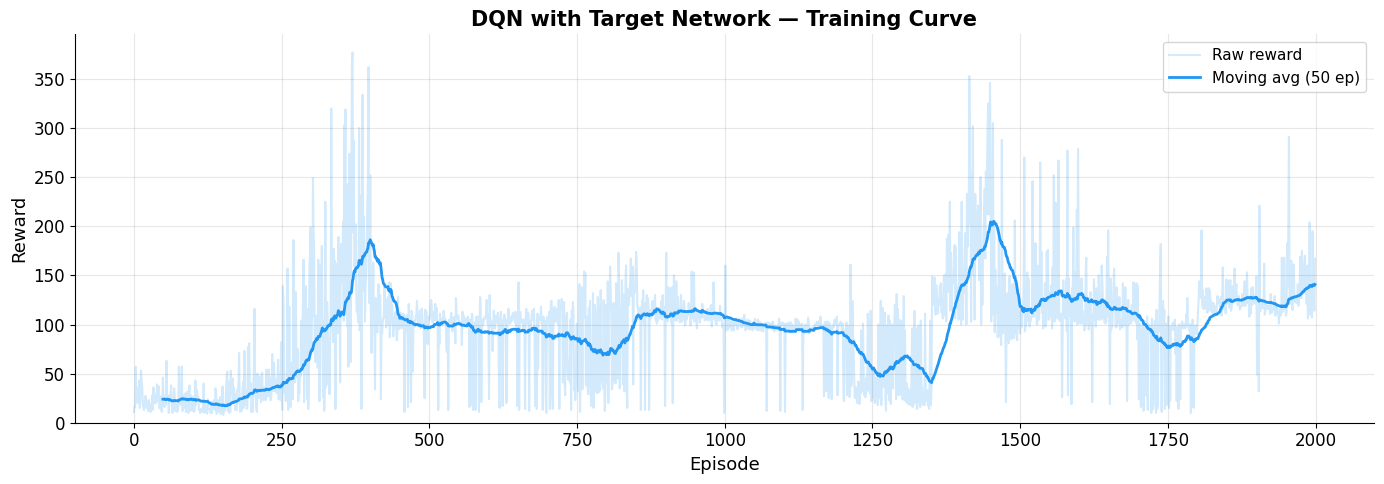

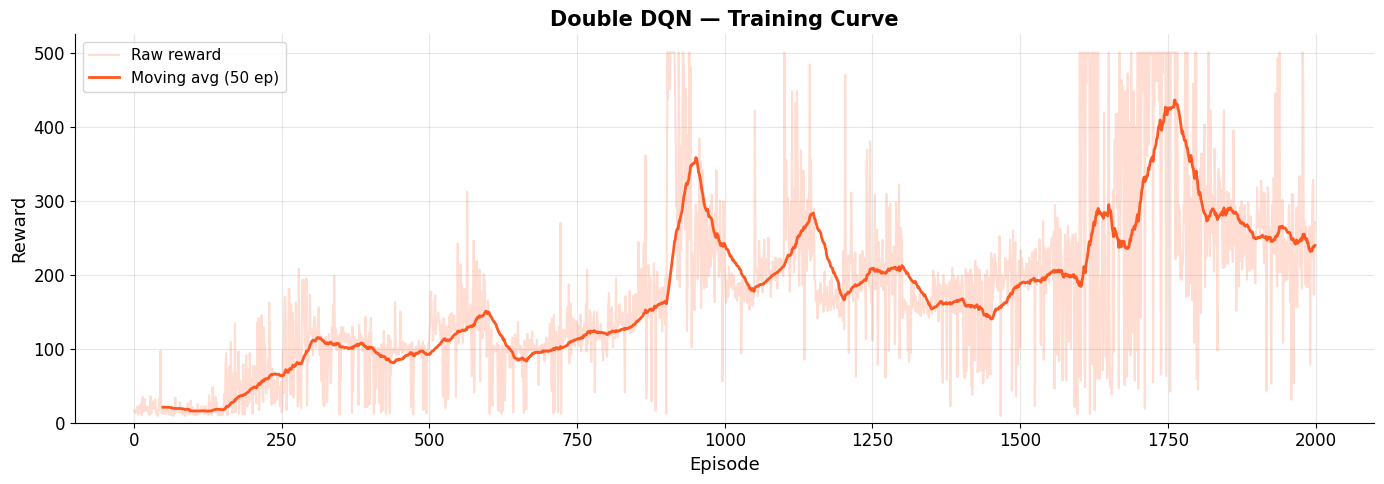

In [20]:
# ── Plot individual training curves ──
plot_reward_curve(rewards_dqn, 'DQN with Target Network — Training Curve', color='#2196F3')
plot_reward_curve(rewards_double_dqn, 'Double DQN — Training Curve', color='#FF5722')

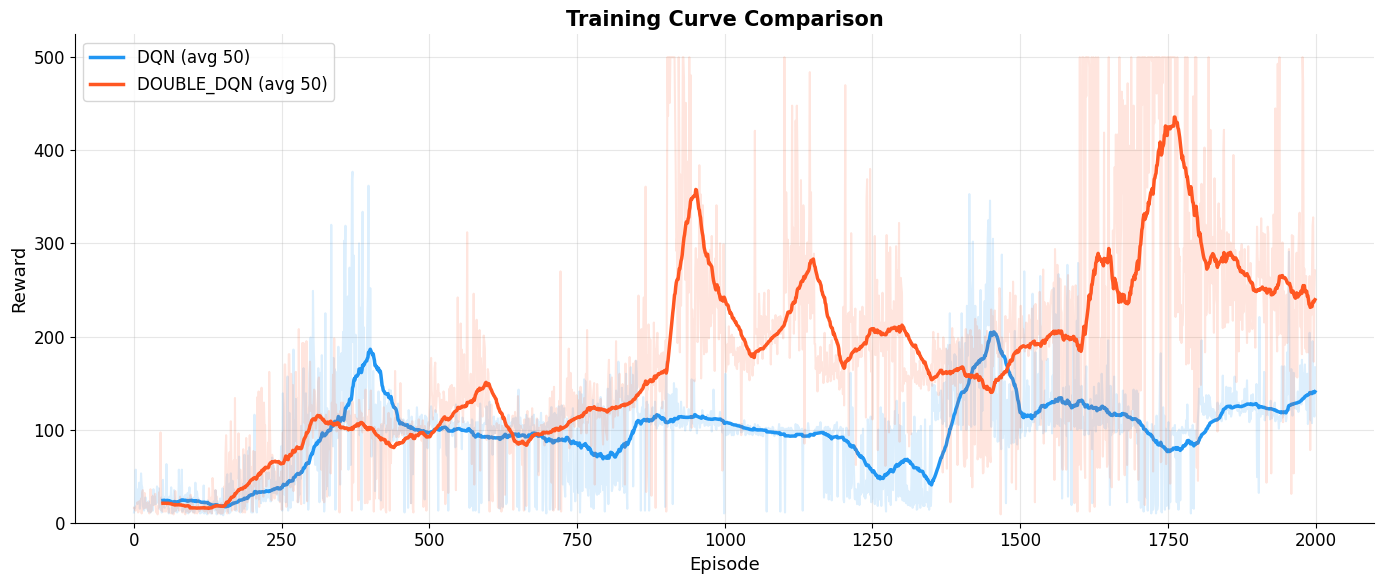

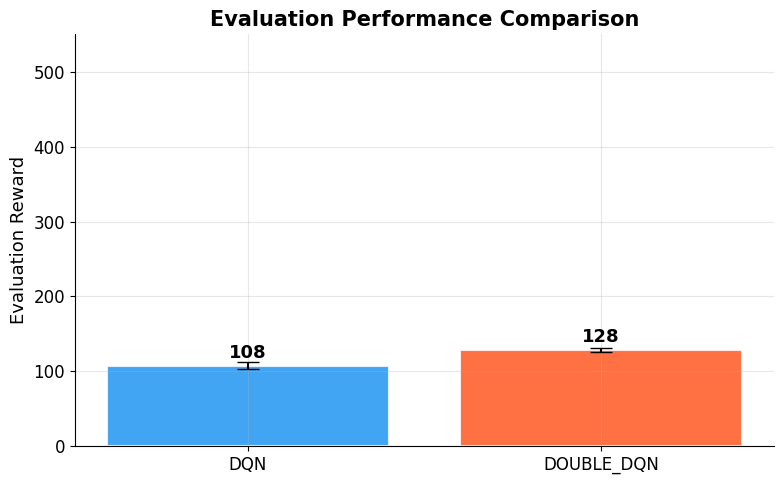

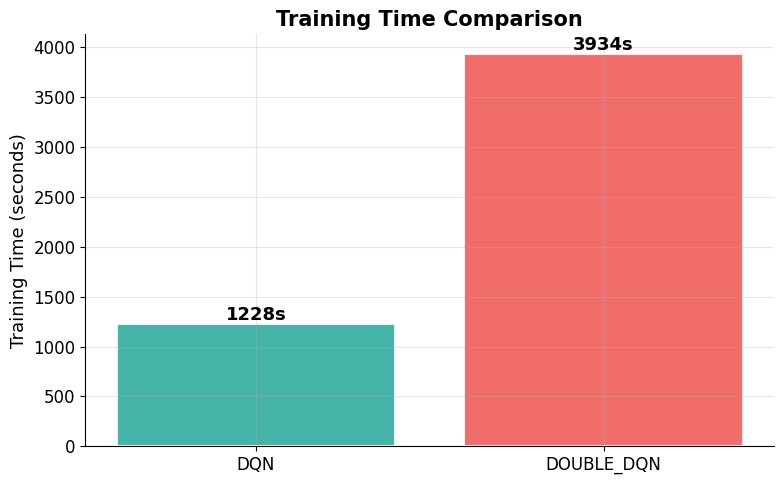

In [21]:
# ── Cross-experiment comparison ──
plot_comparison(experiment_results)
plot_eval_comparison(experiment_results)
plot_timing(experiment_results)

---
## 13. Research Analysis

Automated statistical analysis of all experiments.

In [22]:
def compute_statistics(experiment_results):
    """Compute and display summary statistics for all experiments."""
    print("\n" + "═" * 80)
    print("  RESEARCH ANALYSIS — Summary Statistics")
    print("═" * 80 + "\n")

    # ── Per-experiment statistics ──
    for name, data in experiment_results.items():
        r = np.array(data['training_rewards'])
        print(f"┌── {name} ({data['algorithm']}) ──")
        print(f"│  Mean Reward   : {np.mean(r):.2f}")
        print(f"│  Max Reward    : {np.max(r):.0f}")
        print(f"│  Min Reward    : {np.min(r):.0f}")
        print(f"│  Final Reward  : {r[-1]:.0f}")
        print(f"│  Std Deviation : {np.std(r):.2f}")
        print(f"│  Avg (last 100): {np.mean(r[-100:]):.2f}")
        print(f"│  Train Time    : {data['train_time_sec']:.1f}s ({data['train_time_sec']/60:.1f} min)")
        ep_per_sec = data['num_episodes'] / data['train_time_sec'] if data['train_time_sec'] > 0 else 0
        print(f"│  Ep/sec        : {ep_per_sec:.1f}")
        if data['eval_rewards']:
            print(f"│  Eval Mean     : {np.mean(data['eval_rewards']):.1f}")
            print(f"│  Eval Std      : {np.std(data['eval_rewards']):.1f}")
        print(f"└{'─' * 40}\n")

    # ── Summary comparison table ──
    print("\n  COMPARISON TABLE")
    print("─" * 80)
    header = f"{'Experiment':<18} {'Mean':>8} {'Max':>6} {'Min':>6} {'Std':>8} {'Last100':>8} {'Time(s)':>8}"
    print(header)
    print("─" * 80)
    for name, data in experiment_results.items():
        r = np.array(data['training_rewards'])
        row = (f"{name:<18} {np.mean(r):>8.1f} {np.max(r):>6.0f} "
               f"{np.min(r):>6.0f} {np.std(r):>8.1f} "
               f"{np.mean(r[-100:]):>8.1f} {data['train_time_sec']:>8.1f}")
        print(row)
    print("─" * 80)


compute_statistics(experiment_results)


════════════════════════════════════════════════════════════════════════════════
  RESEARCH ANALYSIS — Summary Statistics
════════════════════════════════════════════════════════════════════════════════

┌── DQN (DQN with Target Network) ──
│  Mean Reward   : 95.88
│  Max Reward    : 377
│  Min Reward    : 8
│  Final Reward  : 167
│  Std Deviation : 53.07
│  Avg (last 100): 129.75
│  Train Time    : 1227.9s (20.5 min)
│  Ep/sec        : 1.6
│  Eval Mean     : 107.6
│  Eval Std      : 4.4
└────────────────────────────────────────

┌── DOUBLE_DQN (Double DQN) ──
│  Mean Reward   : 171.92
│  Max Reward    : 500
│  Min Reward    : 9
│  Final Reward  : 271
│  Std Deviation : 117.18
│  Avg (last 100): 250.93
│  Train Time    : 3934.1s (65.6 min)
│  Ep/sec        : 0.5
│  Eval Mean     : 128.3
│  Eval Std      : 2.3
└────────────────────────────────────────


  COMPARISON TABLE
────────────────────────────────────────────────────────────────────────────────
Experiment             Mean    Max

---
## 14. Conclusions & Research Report

In [23]:
def generate_report(experiment_results):
    """Auto-generate a markdown-formatted research report."""
    total_runtime = time.time() - NOTEBOOK_START_TIME

    report = []
    report.append("\n" + "═" * 70)
    report.append("  📋 RESEARCH REPORT")
    report.append("  CartPole-v1: DQN vs Double DQN")
    report.append("═" * 70)

    report.append("\n  1. EXPERIMENTS CONDUCTED")
    report.append("  " + "─" * 40)
    for name, data in experiment_results.items():
        report.append(f"  • {name}")
        report.append(f"    Algorithm       : {data['algorithm']}")
        report.append(f"    Episodes        : {data['num_episodes']}")
        report.append(f"    Learning Rate   : {data['learning_rate']}")
        report.append(f"    Batch Size      : {data['batch_size']}")
        report.append(f"    Gamma           : {data['gamma']}")
        report.append(f"    Buffer Size     : {data['buffer_size']}")
        report.append(f"    Target Update   : every {data['target_update_freq']} episodes")
        report.append("")

    report.append("\n  2. OBSERVATIONS")
    report.append("  " + "─" * 40)
    for name, data in experiment_results.items():
        r = np.array(data['training_rewards'])
        report.append(f"  • {name}:")
        report.append(f"    - Mean training reward: {np.mean(r):.1f}")
        report.append(f"    - Peak reward achieved: {np.max(r):.0f}")
        report.append(f"    - Final 100-episode avg: {np.mean(r[-100:]):.1f}")
        if data['eval_rewards']:
            report.append(f"    - Evaluation mean: {np.mean(data['eval_rewards']):.1f} ± {np.std(data['eval_rewards']):.1f}")
        report.append("")

    report.append("\n  3. KEY FINDINGS")
    report.append("  " + "─" * 40)

    # ── Determine best performer ──
    best_name = None
    best_avg = -float('inf')
    for name, data in experiment_results.items():
        r = np.array(data['training_rewards'])
        avg = np.mean(r[-100:])
        if avg > best_avg:
            best_avg = avg
            best_name = name

    report.append(f"  • Best final performance: {best_name} (avg last 100: {best_avg:.1f})")

    # ── Both algorithms observed ──
    for name, data in experiment_results.items():
        r = np.array(data['training_rewards'])
        if np.max(r) >= 500:
            report.append(f"  • {name} reached maximum reward (500) during training")

    report.append(f"\n  4. RUNTIME")
    report.append("  " + "─" * 40)
    report.append(f"  • Total notebook runtime: {total_runtime:.1f}s ({total_runtime/60:.1f} min)")
    for name, data in experiment_results.items():
        report.append(f"  • {name} training: {data['train_time_sec']:.1f}s")

    report.append("\n" + "═" * 70)
    report.append("  END OF REPORT")
    report.append("═" * 70)

    print("\n".join(report))


generate_report(experiment_results)


══════════════════════════════════════════════════════════════════════
  📋 RESEARCH REPORT
  CartPole-v1: DQN vs Double DQN
══════════════════════════════════════════════════════════════════════

  1. EXPERIMENTS CONDUCTED
  ────────────────────────────────────────
  • DQN
    Algorithm       : DQN with Target Network
    Episodes        : 2000
    Learning Rate   : 0.001
    Batch Size      : 32
    Gamma           : 0.99
    Buffer Size     : 10000
    Target Update   : every 50 episodes

  • DOUBLE_DQN
    Algorithm       : Double DQN
    Episodes        : 2000
    Learning Rate   : 0.001
    Batch Size      : 32
    Gamma           : 0.99
    Buffer Size     : 10000
    Target Update   : every 50 episodes


  2. OBSERVATIONS
  ────────────────────────────────────────
  • DQN:
    - Mean training reward: 95.9
    - Peak reward achieved: 377
    - Final 100-episode avg: 129.8
    - Evaluation mean: 107.6 ± 4.4

  • DOUBLE_DQN:
    - Mean training reward: 171.9
    - Peak reward achi